# Tutorial 1: Reading Files
This notebook shows how to read the clustering catalogs and clustering measurements. 

In [1]:
# imports
import os
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import logging

# lsstypes allows for easy reading and handling of clustering measurements
import lsstypes as types # https://github.com/adematti/lsstypes/tree/main
# import useful functions from desi-clustering/clustering_statistcs/tools.py
from clustering_statistics.tools import get_catalog_fn, get_stats_fn, base_stats_dir, read_clustering_catalog, _read_catalog, select_region, expand_randoms, setup_logging

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

setup_logging(level=logging.INFO)

Below we define the variables we will use throughout the notebook.

In [2]:
# This cell defines the clustering measurements directories.
# The offical base directory containing the clustering measurements is defined within 
# desi-clustering/clustering_statistcs/tools.py as `base_stats_dir` 
stats_dir = Path(str(base_stats_dir).replace('global','dvs_ro'))
# `analysis` specifies which KP the measurements pertain to.
analysis = 'full_shape'  
# `project` specifies which subfolders to look into with the `analysis` directory. 
# `base` is where official measurements are.
project = f'{analysis}/base' 
# `version` specifies the mocks or data version as defined within `get_catalog_fn`
version = 'holi-v3-altmtl'
print(stats_dir/project/version)

/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v3-altmtl


In [3]:
# Define tracer, region, weights to be used, and zrange...
tracer = 'LRG'
region = 'NGC'
weight = 'default-FKP'
zrange = (0.4, 0.6)
nran   = 1 # number of randoms set to 1 just for this notebook
imock  = 150 # mock realization identifier
FKP_P0 = 1e4 # if WEIGHT_FKP column is not available, use this P0 value to get WEIGHT_FKP = 1. / (1. + NX * FKP_P0)
# for convenience, save in a dictionary
catalog_kws = dict(version=version, tracer=tracer, region=region, weight=weight, zrange=zrange, nran=nran, imock=imock, FKP_P0=FKP_P0)

## Reading Clustering Catalogs

### File manager

Catalog filenames are managed with the `get_catalog_fn` function. 

If the paths to the catalogs you want to load are not available within `get_catalog_fn`, there are two ways you can provide them.

1. If the name of the catalogs follow the standard LSS catalog naming convention, `{tracer}_{region}_clustering.{dat or rand}.{fit or h5}`, you can use `get_catalog_fn` as is by providing the path to the directory that contains the catalogs with `cat_dir=/path/to/catalog/directory/`.

In [4]:
print(get_catalog_fn(cat_dir='/path/to/catalog/directory/', kind='randoms', tracer=tracer, region=region, nran=nran))

[PosixPath('/path/to/catalog/directory/LRG_NGC_0_clustering.ran.h5')]


2. Create your own `get_catalog_fn` function that returns the paths to the catalogs. Below is an example.

In [5]:
def get_my_own_catalog_fn(kind='data', tracer='LRG', region='NGC', nran=10, ext='h5', **kwargs):
    cat_dir='/path/to/catalog/directory/'
    nrans = nran
    if not isinstance(nran, list):
        nrans = list(range(nran))
    cat_dir = Path(cat_dir)
    if kind == 'data':
        return cat_dir / f'{tracer}_{region}_clustering.dat.h5'
    if kind == 'randoms':
        return [cat_dir / f'{tracer}_{region}_{iran:d}_clustering.ran.h5' for iran in nrans]
print(get_my_own_catalog_fn(kind='randoms', tracer=tracer, region=region, nran=nran))

[PosixPath('/path/to/catalog/directory/LRG_NGC_0_clustering.ran.h5')]


In [6]:
# you can also do help(get_catalog_fn) to learn more about its arguments.

### Functions for reading catalogs

If you just want to just load in the catalogs you can use the `_read_catalog` function. This wrapper will read the file whether its a `.fits` or `.h5` file.

In [7]:
randoms = _read_catalog(get_catalog_fn(kind='randoms', **catalog_kws))
print(randoms)

[000000.03] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_0_clustering.ran.h5.
Catalog(csize=16546619, size=16546619, columns=['NX', 'TARGETID', 'TARGETID_DATA', 'WEIGHT'])


In `desi-clustering` we read the clustering catalogs with the `read_clustering_catalog` function (see `help(read_clustering_catalog)`). This function will return the requested catalogs with only the columns neccessary for performing the clustering measurements (if you pass `keep_columns=True` it will return all the columns available). 

This function performs some postprocessing if requested. In the example below, the catalog is cut to the redshift range specified by `zrange`, and region specified by `region` (see `help(select_region)` to learn about the region splits available).

In [8]:
data = read_clustering_catalog(kind='data', get_catalog_fn=get_catalog_fn, **catalog_kws)
print(f'{tracer} {data['Z'].min():.1f} < z < {data['Z'].max():.1f}')
print(data)

[000000.22] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_clustering.dat.h5.
[000000.88] [0/1] 04-27 07:51  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 10000.0
LRG 0.4 < z < 0.6
Catalog(csize=702750, size=702750, columns=['RA', 'DEC', 'Z', 'NX', 'TARGETID', 'INDWEIGHT', 'POSITION'])


If loading randoms for the latest mocks, like the ones saved here `/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/`, you may notice that they only contain columns `['NX', 'TARGETID', 'TARGETID_DATA', 'WEIGHT']`. This was done to save storage space. However, we need `['RA','DEC','Z']` to obtain the positions. This can be handled with the `expand_randoms` functions (see `help(expand_randoms)`), which adds missing columns to the randoms catalogs from parent randoms and data catalogs via TARGETID matches.

For the latest mocks, the parent randoms can be found here `/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/{dark or bright}_{inran}_full_noveto.ran.h5`.

Below is an example on how to use `expand_randoms`.

In [9]:
randoms = _read_catalog(get_catalog_fn(kind='randoms', **catalog_kws))
data    = _read_catalog(get_catalog_fn(kind='data', **(catalog_kws|dict(region='ALL')))) # must load both NGC and SGC, so we override region with 'ALL'
parent_randoms = _read_catalog(get_catalog_fn(kind='parent_randoms', version='data-dr2-v2', tracer=tracer, nran=nran))

expanded_randoms = expand_randoms(randoms, parent_randoms, data)
print(expanded_randoms)

[000004.22] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_0_clustering.ran.h5.
[000004.23] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_clustering.dat.h5.
[000004.23] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_SGC_clustering.dat.h5.
[000004.28] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/code/desi-clustering/main/lib/python3.12/site-packages/clustering_statistics/tools.py:1165: UserWarning: WEIGHT not in catalog
  warnings.warn('WEIGHT not in catalog')


Catalog(csize=16546619, size=16546619, columns=['NX', 'TARGETID', 'TARGETID_DATA', 'WEIGHT', 'RA', 'DEC', 'Z'])


It is easier to expand the randoms using `read_clustering_catalog` by passing a dictionary for `expand` containing the parent randoms filenames.

In [10]:
expand  = {'parent_randoms_fn': get_catalog_fn(kind='parent_randoms', **(catalog_kws | dict(version='data-dr2-v2')))}
randoms = read_clustering_catalog(kind='randoms', expand=expand, **catalog_kws)
print(randoms)

[000015.31] [0/1] 04-27 07:51  tools                     INFO     Expanding randoms
[000015.31] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000015.44] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_clustering.dat.h5.
[000015.44] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_SGC_clustering.dat.h5.
[000015.45] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_0_clustering.ran.h5.
[000025.49] [0/1] 04-27 07:51  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 10000.0
Catalog(csize=3921927, size=3921927, co

### Bonus: Reshuffling Randoms 
To ensure the randoms have the same $n(z)$ as the data, the randoms redshifts are randomly sampled from the redshifts of the data.
To undo this you can reshuffle randoms on-the-fly. This is useful for estimating the radial integral constraing (RIC) from the mocks.

For this you need the merged clustering catalogs in `/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/merged_catalogs/`.

In [11]:
expand  = {'parent_randoms_fn': get_catalog_fn(kind='parent_randoms', **(catalog_kws | dict(version='data-dr2-v2'))), 'from_data': ['Z', 'WEIGHT_SYS', 'FRAC_TLOBS_TILES']} # we need 'FRAC_TLOBS_TILES'
merged_dir = stats_dir / 'merged_catalogs' / version
merged_data_fn = get_catalog_fn(kind='data', cat_dir=merged_dir, **(catalog_kws | dict(region='ALL')))
reshuffle = {'merged_data_fn': merged_data_fn}
randoms = read_clustering_catalog(kind='randoms', expand=expand, reshuffle=reshuffle, **catalog_kws) 
print(randoms)

[000026.56] [0/1] 04-27 07:51  tools                     INFO     Expanding randoms
[000026.56] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000026.69] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_clustering.dat.h5.
[000026.70] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_SGC_clustering.dat.h5.
[000026.70] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_clustering.dat.h5.
[000026.70] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_SGC_clustering.da

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/code/desi-clustering/main/lib/python3.12/site-packages/clustering_statistics/tools.py:1168: UserWarning: TARGETID not in catalog
  warnings.warn('TARGETID not in catalog')


[000027.56] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_NGC_0_clustering.ran.h5.
[000027.56] [0/1] 04-27 07:51  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_SGC_0_clustering.ran.h5.
[000043.70] [0/1] 04-27 07:52  tools                     INFO     Reshuffling randoms started.
[000061.81] [0/1] 04-27 07:52  tools                     INFO     alpha after renormalization & reweighting: [1.00040666 0.99991288]
[000061.87] [0/1] 04-27 07:52  tools                     INFO     Reshuffling randoms completed in 18.2 s
[000062.79] [0/1] 04-27 07:52  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 10000.0
Catalog(csize=3930377, size=3930377, columns=['RA', 'DEC', 'Z', 'NX', 'TARGETID', 'INDWEIGHT', 'POSITION'])


### Bonus: Complete Mocks
Create completeness-weighted complete (i.e. "without fiber assignment") mocks. Useful for estimating the impact of fiber assignment.

In [12]:
# Pass complete = {} to create a complete data catalog on-the-fly
# And reshuffle to store the new (complete) data catalog to resample redshifts from in cache
complete, reshuffle = {}, {}
data = read_clustering_catalog(kind='data', complete=complete, reshuffle=reshuffle, **catalog_kws)
print(data)

[000064.02] [0/1] 04-27 07:52  tools                     INFO     On-the-fly complete data.
[000064.07] [0/1] 04-27 07:52  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl150/loa-v1/mock150/LSScats/LRG_full_HPmapcut.dat.h5.
[000064.45] [0/1] 04-27 07:52  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/forFA150.fits.
[000083.08] [0/1] 04-27 07:52  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 10000.0
Catalog(csize=853962, size=853962, columns=['RA', 'DEC', 'Z', 'NX', 'TARGETID', 'INDWEIGHT', 'POSITION'])


## Reading Clustering Measurements

### File manager

Similarly as for the catalogs, the generation of the statistics filenames are handled with a function, `get_stats_fn` (see `help(get_stats_fn)`).

The kind of measurement is handled with `kind`. Here we list the most relevant.

* `particle2_correlation`: two-point correlation function (2PCF).
* `mesh2_spectrum`: power spectrum.
* `mesh3_spectrum`: bispectrum.
* `window_mesh2_spectrum`: power spectrum window matrix.
* `window_mesh3_spectrum`: bispectrum window matrix.
* `covariance_mesh2_spectrum`: power spectrum analytical covariance.

In [13]:
kind = 'mesh2_spectrum'
stats_kws = dict(stats_dir=stats_dir, version=version, project=project, tracer=tracer, zrange=zrange, region=region, weight=weight, basis='sugiyama-diagonal') # for bispectra you must specify `basis` (sugiyama or scoccimarro)
fn = get_stats_fn(**stats_kws, kind=kind, imock=imock)
print(fn)

/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v3-altmtl/mock150/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP.h5


### Reading and handling stats with `lsstypes.types`

Stats can be read with `types.read`. In addition to reading the stats files, `types` has very useful utilities for combining, slicing and rebinning the measurements. It also has the functionality of estimating the mean and covariance from the measurements.  

In [14]:
imocks = np.arange(100) # or you can set imock='*' which will look for all readable measurements and return them as a list of paths
fns = [get_stats_fn(**stats_kws, kind=kind, imock=imock) for imock in imocks]
fns = [fn for fn in fns if fn.exists()] # this makes sure the measurements exists
stats = [types.read(fn) for fn in fns]
mean  = types.mean(stats)  # compute mean from stats
cov   = types.cov(stats).at.observable.match(mean) # estimate the covariance from the mocks and match binning of mean

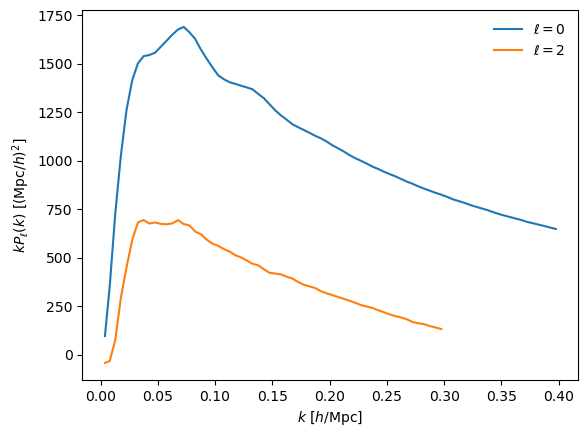

In [15]:
mean = mean.select(k=slice(0, None, 5))  # rebin to dk = 0.005 h/Mpc
mean = mean.select(k=(0., 0.4))  # select k-range
mean = mean.get(ells=[0, 2])  # monopole and quadrupole
mean = mean.at(ells=[2]).select(k=(0., 0.3))  # apply stricter k-cut to the quadrupole
mean.plot(show=True); # simple plotting

### Plotting stats

The examples below shows how to extract information from the stats files and plot them.

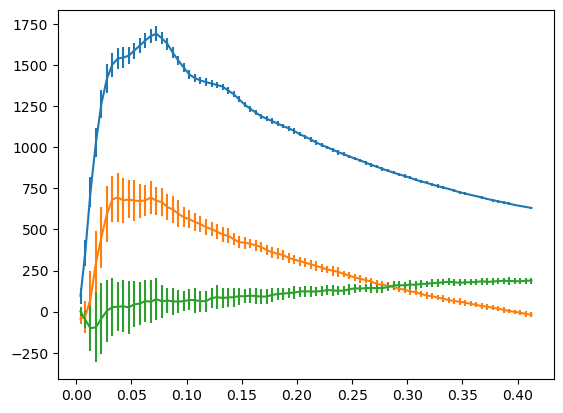

In [16]:
kind = 'mesh2_spectrum'
rebin = 5 # factor used for rebinning the measurement.

ells = [(0,0,0),(2,0,2)] if 'mesh3' in kind else [0,2,4]
fns = [get_stats_fn(**stats_kws, kind=kind, imock=imock) for imock in imocks]
fns = [fn for fn in fns if fn.exists()] 

# read measurements
if 'particle2_correlation' in kind:
    stats = [types.read(fn).project(ells=ells).select(s=slice(0, None, rebin)) for fn in fns]
else:
    stats = [types.read(fn).select(k=slice(0, None, rebin)) for fn in fns]    
mean = types.mean(stats) 
cov  = types.cov(stats).at.observable.match(mean) 

# plot
ax = plt.gca()
for ell in mean.ells:
    poles = mean.get(ell)
    if 'particle2' in kind: x = poles.coords('s')
    if 'mesh2' in kind: x = poles.coords('k')
    if 'mesh3' in kind: x = poles.coords('k')[..., 0]
    value =  x * poles.value().real if 'mesh2' in kind else x**2 * poles
    std = cov.at.observable.get(ell).std().real
    std = x * std if 'mesh2' in kind else x**2 * std
    ax.errorbar(x, value, yerr=std)
plt.show()    

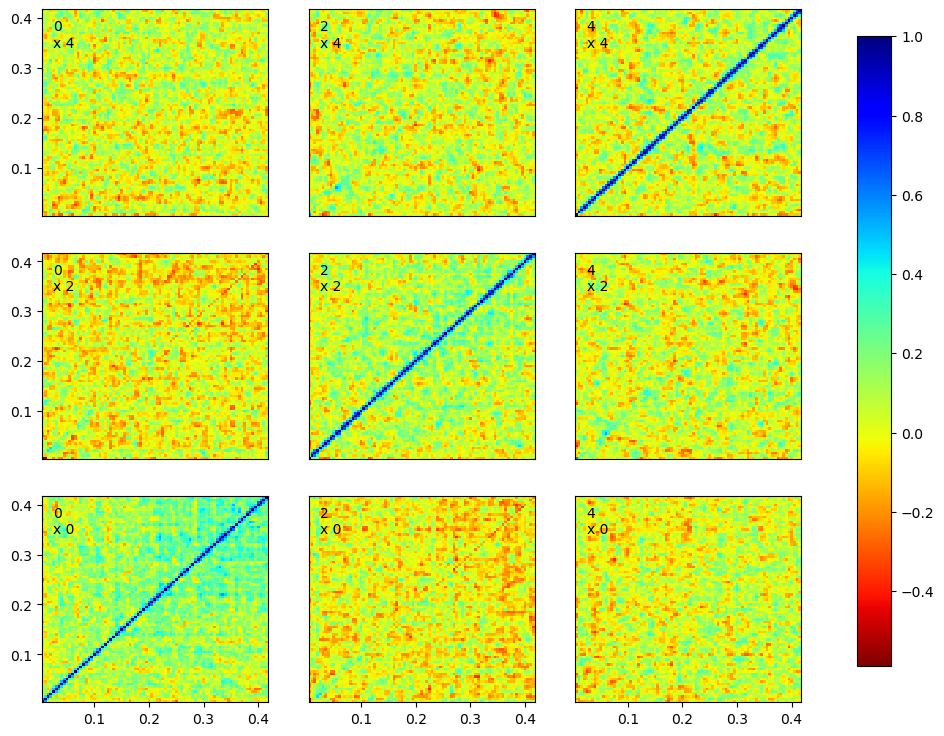

In [17]:
# plot correlation matrix
cov.plot(corrcoef=True, show=True);

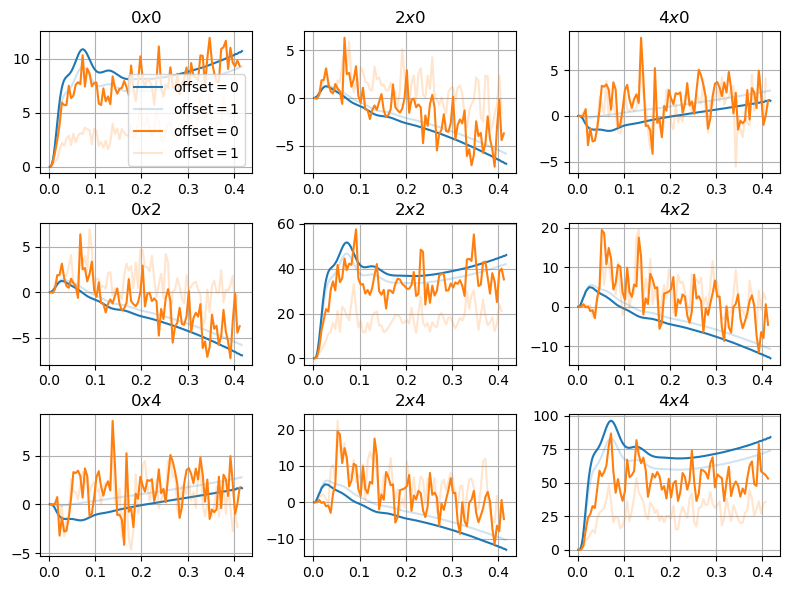

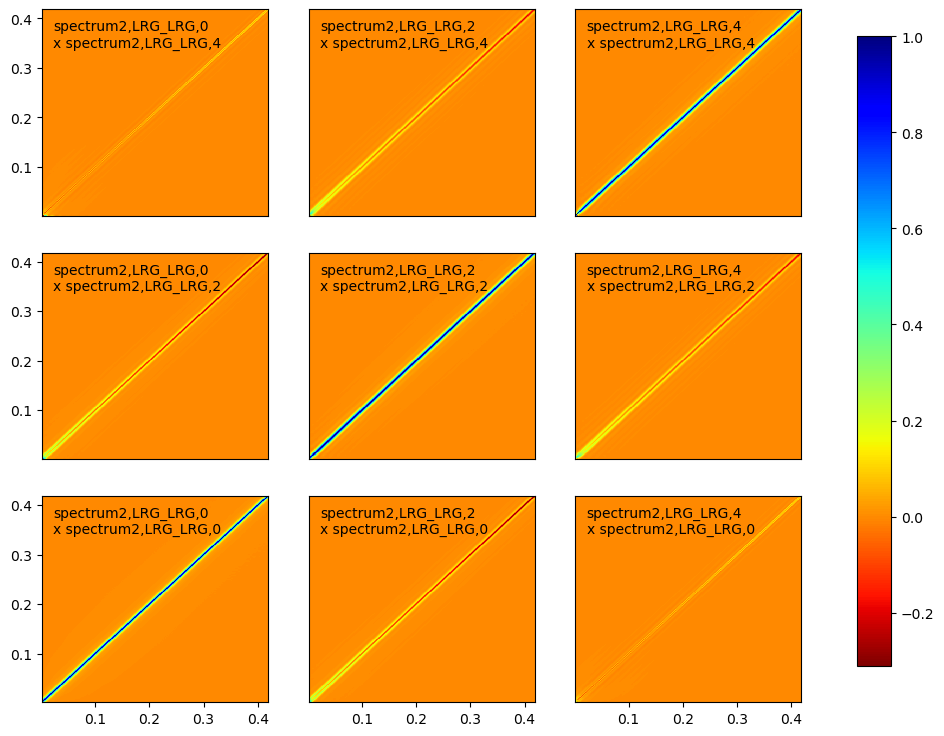

In [18]:
fn = get_stats_fn(**stats_kws, kind=f'covariance_{kind}', imock=0)
cov_analytic = types.read(fn)# at.observable.get(observables='spectrum2', tracers=(tracer,) * 2)

kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
fig = cov_analytic.plot_diag(**kw, show=False, color='C0')
cov.plot_diag(**kw, fig=fig, color='C1', show=True)
cov_analytic.plot(corrcoef=True, show=True);

In this notebook we only used Holi mocks. If you are searching for other measurements, look within the directories below:

In [19]:
!tree -d -L 3 $base_stats_dir | grep -vE '(complete)'

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics
├── abacus-2ndgen
├── auxiliary_data
├── bao
│   └── base
├── box
│   └── abacus-2ndgen
├── full_shape
│   ├── base
│   │   ├── abacus-2ndgen-dr2-altmtl
│   │   ├── abacus-hf-dr2-v2-altmtl
│   │   ├── glam-uchuu-v1-altmtl
│   │   ├── glam-uchuu-v2-altmtl
│   │   ├── holi-v1-altmtl
│   │   ├── holi-v3-altmtl
│   │   └── uchuu-hf-altmtl
│   ├── data_splits
│   │   ├── abacus-hf-dr2-v2-altmtl
│   │   ├── blinded_data
│   │   ├── glam-uchuu-v2-altmtl
│   │   └── holi-v3-altmtl
│   ├── fiber_assignment_systematics
│   │   └── abacus-hf-dr2-v2-altmtl
│   └── multitracer
│       ├── abacus-hf-dr2-v1-box
│       ├── abacus-hf-dr2-v2-altmtl
│       ├── abacus-hf-dr2-v2-box
│       └── holi-v3-altmtl
├── local_png
│   ├── base
│   │   ├── glam-uchuu-v1-altmtl
│   │   ├── holi-v3-altmtl
│   │   └── remove-holi-v3-altmtl
│   └── test
│       └── holi-v3-altmtl
├── merged_catalogs
│   ├── glam-uchuu-v1-altmtl
│   └── holi-v3-